# Distributed Data Processing with PySpark

## The Dataset: NYC Taxi Trips

**1. Download the Dataset**

In [1]:
import urllib.request
import os

os.makedirs("../data/taxi", exist_ok=True)

files = [
    "yellow_tripdata_2023-01.parquet",
    "yellow_tripdata_2023-02.parquet",
]

base_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/"
dest_dir = "../data/taxi"

for filename in files:
    dest = os.path.join(dest_dir, filename)
    if os.path.exists(dest):
        print(f"Already exists, skipping: {dest}")
        continue
    url = base_url + filename
    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(url, dest)
    print(f"Downloaded to {dest}")

Already exists, skipping: ../data/taxi\yellow_tripdata_2023-01.parquet
Downloaded to ../data/taxi\yellow_tripdata_2023-02.parquet


**2. Verify the File with Pandas (optional)**

In [2]:
import pandas as pd

sample = pd.read_parquet("../data/taxi/yellow_tripdata_2023-01.parquet")
print(sample.shape)    # (3066766, 19)
print(sample.dtypes)

(3066766, 19)
VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
dtype: object


**3. Chapter setup cell**

In [8]:
import os
import sys
import warnings
import pyspark.pandas as ps

# Critical fix for virtualenv on Windows
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# Increase timeouts significantly (helps a lot on Windows)
os.environ["SPARK_NETWORK_TIMEOUT"] = "1000s"
os.environ["SPARK_EXECUTOR_HEARTBEAT_INTERVAL"] = "120s"

# Optional: extra configs for stability
os.environ["PYSPARK_SUBMIT_ARGS"] = "--conf spark.python.worker.reuse=true pyspark-shell"

# Tell PyArrow to ignore timezone metadata
os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"

# Suppress only this specific warning
warnings.filterwarnings("ignore", category=ps.utils.PandasAPIOnSparkAdviceWarning)

**Then create the shared session and load the dataset:**

In [3]:
# ── session and data — run this cell second 
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, round, when, unix_timestamp, lit,
    avg, count, stddev, sum as spark_sum,
    hour, month, broadcast
)
import pyspark.sql.functions as F

# PySpark 4.x uses Spark Connect by default — no .master() required.
# For classic local mode on PySpark 3.x, add .master("local[*]").
spark = (
    SparkSession.builder
    .appName("NYC Taxi Analysis")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

df = spark.read.parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet"
)

print(f"Spark {spark.version} — {df.count():,} rows loaded")

Spark 4.1.1 — 3,066,766 rows loaded


## When Data Becomes Too Large

### The single-machine ceiling

In [4]:
import pandas as pd

# This works for January 2023 (47 MB Parquet → ~300 MB in memory)
df_small = pd.read_parquet("../data/taxi/yellow_tripdata_2023-01.parquet")
print(f"Memory: {df_small.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Loading all of 2023 (12 months × ~300 MB ≈ 3.6 GB) starts to strain
# a 16 GB machine when intermediate results are included.
# The full historical dataset (2009–2023) exceeds 500 GB in memory.

Memory: 593.1 MB


## Spark Architecture

### Lazy evaluation in Spark

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, round

spark = (
    SparkSession.builder
    .appName("NYC Taxi Analysis")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

df = spark.read.parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet"
)

# All of these are lazy — no data is read yet
lazy_pipeline = (
    df.filter(col("trip_distance") > 0)
      .select(
          "tpep_pickup_datetime",
          "trip_distance",
          "fare_amount",
          round(col("fare_amount") / col("trip_distance"), 2)
            .alias("fare_per_mile")
      )
)

# This action triggers execution of the entire pipeline
lazy_pipeline.show(5)

+--------------------+-------------+-----------+-------------+
|tpep_pickup_datetime|trip_distance|fare_amount|fare_per_mile|
+--------------------+-------------+-----------+-------------+
| 2023-01-01 00:32:10|         0.97|        9.3|         9.59|
| 2023-01-01 00:55:08|          1.1|        7.9|         7.18|
| 2023-01-01 00:25:04|         2.51|       14.9|         5.94|
| 2023-01-01 00:03:48|          1.9|       12.1|         6.37|
| 2023-01-01 00:10:29|         1.43|       11.4|         7.97|
+--------------------+-------------+-----------+-------------+
only showing top 5 rows


## Spark DataFrames

### Loading data into a Spark DataFrame

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("NYC Taxi Analysis")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

df = spark.read.parquet("../data/taxi/yellow_tripdata_2023-01.parquet")

print(type(df))

<class 'pyspark.sql.classic.dataframe.DataFrame'>


### Inspecting the schema and shape

In [7]:
df.printSchema()

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)



In [8]:
print(df.count())        # 3066766
print(len(df.columns))  # 19

3066766
19


In [9]:
# Descriptive statistics — also an action
df.select(
    "trip_distance", "fare_amount", "tip_amount", "total_amount"
).describe().show()

+-------+------------------+------------------+------------------+------------------+
|summary|     trip_distance|       fare_amount|        tip_amount|      total_amount|
+-------+------------------+------------------+------------------+------------------+
|  count|           3066766|           3066766|           3066766|           3066766|
|   mean|3.8473420306601414| 18.36706861234247|3.3679406710526827| 27.02038310708492|
| stddev|249.58375606858166|17.807821939337924| 3.826759457294151|22.163588952492184|
|    min|               0.0|            -900.0|            -96.22|            -751.0|
|    max|         258928.15|            1160.1|             380.8|            1169.4|
+-------+------------------+------------------+------------------+------------------+



**keep 2 decimal places**

In [11]:
from pyspark.sql.functions import format_number, col

# Run describe and format numeric stats to 2 decimal places
df.select(
    "trip_distance", "fare_amount", "tip_amount", "total_amount"
).describe().select(
    "summary",
    format_number(col("trip_distance").cast("double"), 2).alias("trip_distance"),
    format_number(col("fare_amount").cast("double"), 2).alias("fare_amount"),
    format_number(col("tip_amount").cast("double"), 2).alias("tip_amount"),
    format_number(col("total_amount").cast("double"), 2).alias("total_amount")
).show(truncate=False)

+-------+-------------+------------+------------+------------+
|summary|trip_distance|fare_amount |tip_amount  |total_amount|
+-------+-------------+------------+------------+------------+
|count  |3,066,766.00 |3,066,766.00|3,066,766.00|3,066,766.00|
|mean   |3.85         |18.37       |3.37        |27.02       |
|stddev |249.58       |17.81       |3.83        |22.16       |
|min    |0.00         |-900.00     |-96.22      |-751.00     |
|max    |258,928.15   |1,160.10    |380.80      |1,169.40    |
+-------+-------------+------------+------------+------------+



### Selecting and filtering

In [12]:
from pyspark.sql.functions import col

# Select a subset of columns
subset = df.select(
    "tpep_pickup_datetime",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "payment_type"
)

# Filter: trips with positive distance and positive fare
clean = subset.filter(
    (col("trip_distance") > 0) &
    (col("fare_amount") > 0) &
    (col("total_amount") > 0)
)

print(clean.count())    # 2998382

2998382


In [13]:
# Chained filters using method chaining
long_trips = (
    df.filter(col("trip_distance") > 10)
      .filter(col("payment_type") == 1)
      .filter(col("passenger_count") >= 1)
)

print(long_trips.count())    # 190999

190999


### Adding and transforming columns

In [3]:
from pyspark.sql.functions import col, round, when, unix_timestamp

df_enriched = (
    df.filter((col("trip_distance") > 0) & (col("fare_amount") > 0))
      .select(
          "tpep_pickup_datetime",
          "tpep_dropoff_datetime",
          "trip_distance",
          "fare_amount",
          "tip_amount",
          "total_amount",
          "payment_type",
          "PULocationID",

          # Fare per mile
          round(col("fare_amount") / col("trip_distance"), 2)
            .alias("fare_per_mile"),

          # Trip duration in minutes
          round(
              (unix_timestamp("tpep_dropoff_datetime") -
               unix_timestamp("tpep_pickup_datetime")) / 60.0, 2
          ).alias("duration_min"),

          # Tip percentage relative to fare
          round(col("tip_amount") / col("fare_amount") * 100, 1)
            .alias("tip_pct"),

          # Distance tier label
          when(col("trip_distance") < 1,  "short")
          .when(col("trip_distance") < 5,  "medium")
          .when(col("trip_distance") < 15, "long")
          .otherwise("very_long")
          .alias("distance_tier"),
      )
)

df_enriched.select(
    "trip_distance", "fare_amount", "fare_per_mile",
    "duration_min", "tip_pct", "distance_tier"
).show(5)

+-------------+-----------+-------------+------------+-------+-------------+
|trip_distance|fare_amount|fare_per_mile|duration_min|tip_pct|distance_tier|
+-------------+-----------+-------------+------------+-------+-------------+
|         0.97|        9.3|         9.59|        8.43|    0.0|        short|
|          1.1|        7.9|         7.18|        6.32|   50.6|       medium|
|         2.51|       14.9|         5.94|       12.75|  100.7|       medium|
|          1.9|       12.1|         6.37|        9.62|    0.0|       medium|
|         1.43|       11.4|         7.97|       10.83|   28.8|       medium|
+-------------+-----------+-------------+------------+-------+-------------+
only showing top 5 rows


### Writing output

In [4]:
import os
os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"
os.environ["HADOOP_HOME"]             = r"C:\hadoop"
os.environ["hadoop.home.dir"]         = r"C:\hadoop"

# Write to Parquet (partitioned by distance_tier for efficient downstream reads)
(
    df_enriched
    .write
    .mode("overwrite")
    .partitionBy("distance_tier")
    .parquet("../data/taxi/enriched/")
)

# Write to CSV (useful for small result sets)
(
    df_enriched
    .filter(col("trip_distance") > 20)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv("../data/taxi/long_trips_csv/")
)

print("Write successful.")

Write successful.


Correct the error

## Pandas API on Spark

### Creating a pandas-on-Spark DataFrame

In [18]:
import os
import sys
import warnings

os.environ["PYSPARK_PYTHON"]          = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"]   = sys.executable
os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"
os.environ["HADOOP_HOME"]             = r"C:\hadoop"
os.environ["hadoop.home.dir"]         = r"C:\hadoop"

from pyspark.sql import SparkSession
from pyspark.pandas.utils import PandasAPIOnSparkAdviceWarning
warnings.filterwarnings("ignore", category=PandasAPIOnSparkAdviceWarning)

spark = (
    SparkSession.builder
    .appName("NYC Taxi Pandas API")
    .config("spark.driver.memory", "4g")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.python.worker.timeout", "120")
    .getOrCreate()
)

spark = (
    SparkSession.builder
    .appName("NYC Taxi Pandas API")
    .config("spark.driver.memory", "4g")
    .config("spark.python.worker.timeout", "120")
    .getOrCreate()
)

# --- Method 1: convert an existing Spark DataFrame ---
sdf = spark.read.parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet"
)
psdf = sdf.pandas_api()

print(type(psdf))
# <class 'pyspark.pandas.frame.DataFrame'>
print(psdf.shape)
# (3066766, 19)

# --- Method 2: read directly with the pandas-on-Spark API ---
psdf2 = ps.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
)
print(psdf2.shape)   # (3066766, 19)

# --- Method 3: select columns at read time (preferred over ps.from_pandas) ---
psdf3 = ps.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    index_col=None,
    columns=["trip_distance", "fare_amount", "tip_amount", "payment_type"]
)
print(psdf3.shape)   # (3066766, 4)

<class 'pyspark.pandas.frame.DataFrame'>
(3066766, 19)
(3066766, 19)
(3066766, 4)


### Familiar operations on distributed data

In [19]:
import pyspark.pandas as ps

psdf = ps.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    index_col=None
)

# Select columns — identical to Pandas
subset = psdf[["trip_distance", "fare_amount",
               "tip_amount", "payment_type"]]

# Boolean filtering — identical to Pandas
clean = subset[
    (subset["trip_distance"] > 0) &
    (subset["fare_amount"] > 0)
]

print(clean.shape)    # (2959680, 4)

# head() and describe() — identical to Pandas
print(clean.head(3))
print(clean.describe().round(2))

(2998382, 4)
   trip_distance  fare_amount  tip_amount  payment_type
0           0.97          9.3         0.0             2
1           1.10          7.9         4.0             1
2           2.51         14.9        15.0             1
       trip_distance  fare_amount  tip_amount  payment_type
count     2998382.00   2998382.00  2998382.00    2998382.00
mean            3.89        18.56        3.41          1.17
std           249.82        16.99        3.77          0.48
min             0.01         0.01       -5.78          0.00
25%             1.10         8.60        1.00          1.00
50%             1.80        12.80        2.80          1.00
75%             3.40        20.50        4.20          1.00
max        258928.15      1160.10      380.80          4.00


### Adding columns and applying functions

In [24]:
import pyspark.pandas as ps

psdf = ps.read_parquet("../data/taxi/yellow_tripdata_2023-01.parquet")

clean = psdf[
    (psdf["trip_distance"] > 0) & (psdf["fare_amount"] > 0)
].copy()

clean["fare_per_mile"] = (clean["fare_amount"] / clean["trip_distance"]).round(2)
clean["tip_pct"]       = (clean["tip_amount"] / clean["fare_amount"] * 100).round(1)

# ps.cut() is not implemented — use .mask() to assign bins
clean["distance_tier"] = "very_long"
clean["distance_tier"] = (
    clean["distance_tier"]
    .mask(clean["trip_distance"] <= 1, "short")
    .mask((clean["trip_distance"] > 1) & (clean["trip_distance"] <= 5),  "medium")
    .mask((clean["trip_distance"] > 5) & (clean["trip_distance"] <= 15), "long")
)

print(
    clean[["trip_distance", "fare_per_mile",
           "tip_pct", "distance_tier"]].head(4)
)

   trip_distance  fare_per_mile  tip_pct distance_tier
0           0.97           9.59      0.0         short
1           1.10           7.18     50.6        medium
2           2.51           5.94    100.7        medium
3           1.90           6.37      0.0        medium


### Group-by and aggregation

In [25]:
import pyspark.pandas as ps

psdf = ps.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet"
)

clean = psdf[
    (psdf["trip_distance"] > 0) & (psdf["fare_amount"] > 0)
].copy()

clean["tip_pct"] = (
    clean["tip_amount"] / clean["fare_amount"] * 100
).round(1)

# Per-payment-type summary — identical Pandas groupby syntax
payment_summary = (
    clean.groupby("payment_type")
    .agg(
        n_trips       =("fare_amount", "count"),
        avg_fare      =("fare_amount", "mean"),
        avg_tip_pct   =("tip_pct",     "mean"),
        avg_distance  =("trip_distance","mean"),
    )
    .round(2)
    .sort_values("n_trips", ascending=False)
    .reset_index()
)

print(payment_summary)

   payment_type  n_trips  avg_fare  avg_tip_pct  avg_distance
0             1  2390461     18.50        25.97          3.47
1             2   517040     18.53         0.00          3.46
2             0    64201     21.19        20.23         23.42
3             4    16535     18.81         0.14          3.26
4             3    10145     17.29         0.02          3.03


### Joining two pandas-on-Spark DataFrames

In [32]:
import pyspark.pandas as ps
import pandas as pd

psdf = ps.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet"
)

# Load the zone lookup table from local CSV
zones_ps = ps.read_csv("../data/taxi/taxi_zone_lookup.csv")

# Rename for clarity
zones_ps = zones_ps.rename(columns={
    "LocationID": "PULocationID",
    "Borough":    "pickup_borough",
    "Zone":       "pickup_zone",
})

# merge() — same as pd.merge(), executes as a Spark join
trips_named = psdf.merge(
    zones_ps[["PULocationID", "pickup_borough", "pickup_zone"]],
    on="PULocationID",
    how="left"
)

# Borough-level summary
borough_summary = (
    trips_named[trips_named["trip_distance"] > 0]
    .groupby("pickup_borough")
    .agg(
        n_trips      =("fare_amount", "count"),
        avg_fare     =("fare_amount", "mean"),
        avg_distance =("trip_distance", "mean"),
    )
    .round(2)
    .sort_values("n_trips", ascending=False)
    .reset_index()
)
print(borough_summary)

  pickup_borough  n_trips  avg_fare  avg_distance
0      Manhattan  2686017     14.72          2.92
1         Queens   276224     51.11         12.79
2        Unknown    38568     26.48          7.87
3       Brooklyn    16069     25.96          6.39
4          Bronx     3149     29.91          7.00
5            N/A      525     68.26          7.53
6  Staten Island      267     46.75         14.50
7            EWR       85     86.84          7.69


### Key differences from standard Pandas

In [11]:
import pyspark.pandas as ps

# Tell pyspark.pandas NOT to create a default index
psdf1 = ps.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet", 
    index_col=None
)

psdf2 = ps.read_parquet(
    "../data/taxi/yellow_tripdata_2023-02.parquet", 
    index_col=None
)

common_cols = sorted(set(psdf1.columns) & set(psdf2.columns))

psdf1 = psdf1[common_cols]
psdf2 = psdf2[common_cols]

combined = ps.concat([psdf1, psdf2], ignore_index=True)

# Your display code
cols_to_show = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime', 
    'trip_distance', 
]

print("Combined shape:", combined.shape)
print("\nFirst 5 rows:")
print(combined[cols_to_show].head(5))

Combined shape: (5980721, 18)

First 5 rows:
  tpep_pickup_datetime tpep_dropoff_datetime  trip_distance
0  2023-01-01 00:32:10   2023-01-01 00:40:36           0.97
1  2023-01-01 00:55:08   2023-01-01 01:01:27           1.10
2  2023-01-01 00:25:04   2023-01-01 00:37:49           2.51
3  2023-01-01 00:03:48   2023-01-01 00:13:25           1.90
4  2023-01-01 00:10:29   2023-01-01 00:21:19           1.43


### When to use the Pandas API on Spark vs the native DataFrame API

In [9]:
import pyspark.pandas as ps
from pyspark.sql import SparkSession
from pyspark.sql.functions import broadcast, col, avg, count, round

# Better set via .config() — guaranteed to reach Spark
spark = SparkSession.builder \
    .appName("NYC Taxi") \
    .config("spark.network.timeout", "1000s") \
    .config("spark.executor.heartbeatInterval", "120s") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

psdf = ps.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet"
)

# Engineer features with Pandas syntax
psdf["fare_per_mile"] = (
    psdf["fare_amount"] / psdf["trip_distance"]
).round(2)

# Convert back to native Spark DataFrame for the broadcast join
sdf = psdf.to_spark()

# Use native Spark for the performance-critical join
zones_sdf = spark.createDataFrame(
    ps.read_csv(
        "../data/taxi/taxi_zone_lookup.csv"
    ).to_pandas()
)

result = (
    sdf.filter(col("trip_distance") > 0)
       .join(
           broadcast(zones_sdf.select(
               col("LocationID").alias("PULocationID"),
               col("Borough").alias("pickup_borough")
           )),
           on="PULocationID",
           how="left"
       )
       .groupBy("pickup_borough")
       .agg(
           count("*").alias("n_trips"),
           round(avg("fare_per_mile"), 2).alias("avg_fare_per_mile")
       )
       .orderBy("n_trips", ascending=False)
)

result.show()

+--------------+-------+-----------------+
|pickup_borough|n_trips|avg_fare_per_mile|
+--------------+-------+-----------------+
|     Manhattan|2686017|             9.09|
|        Queens| 276224|            10.61|
|       Unknown|  38568|            15.29|
|      Brooklyn|  16069|            14.83|
|         Bronx|   3149|             18.9|
|           N/A|    525|           334.95|
| Staten Island|    267|            10.01|
|           EWR|     85|          2125.22|
+--------------+-------+-----------------+



## Spark SQL

### Registering a temporary view

In [10]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, round, unix_timestamp, when

spark = (
    SparkSession.builder
    .appName("NYC Taxi SQL")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

df = spark.read.parquet("../data/taxi/yellow_tripdata_2023-01.parquet")

# Build the enriched DataFrame using select()
df_enriched = (
    df.filter((col("trip_distance") > 0) & (col("fare_amount") > 0))
      .select(
          "tpep_pickup_datetime",
          "trip_distance",
          "fare_amount",
          "tip_amount",
          "total_amount",
          "payment_type",
          "PULocationID",
          round(col("fare_amount") / col("trip_distance"), 2)
            .alias("fare_per_mile"),
          round(
              (unix_timestamp("tpep_dropoff_datetime") -
               unix_timestamp("tpep_pickup_datetime")) / 60.0, 2
          ).alias("duration_min"),
          round(col("tip_amount") / col("fare_amount") * 100, 1)
            .alias("tip_pct"),
          when(col("trip_distance") < 1,  "short")
          .when(col("trip_distance") < 5,  "medium")
          .when(col("trip_distance") < 15, "long")
          .otherwise("very_long")
          .alias("distance_tier"),
      )
)

# Register as a SQL-queryable view
df_enriched.createOrReplaceTempView("taxi")

print("View registered.")

View registered.


### Querying with spark.sql()

In [11]:
# Basic SELECT with WHERE
result = spark.sql("""
    SELECT
        tpep_pickup_datetime,
        trip_distance,
        fare_amount,
        tip_pct
    FROM taxi
    WHERE trip_distance > 10
      AND payment_type = 1
    ORDER BY fare_amount DESC
    LIMIT 10
""")

result.show()

+--------------------+-------------+-----------+-------+
|tpep_pickup_datetime|trip_distance|fare_amount|tip_pct|
+--------------------+-------------+-----------+-------+
| 2023-01-31 21:14:09|        141.2|      521.0|    0.0|
| 2023-01-13 15:39:36|        72.61|      472.7|    1.1|
| 2023-01-09 17:42:42|         77.4|      472.0|   10.6|
| 2023-01-08 17:12:37|        82.04|      466.0|    2.1|
| 2023-01-21 16:07:45|         75.6|      450.0|    0.0|
| 2023-01-13 16:25:28|        71.14|      444.7|    5.6|
| 2023-01-29 21:48:35|        70.43|      426.5|    0.0|
| 2023-01-16 06:20:00|        62.54|      424.4|    0.0|
| 2023-01-11 16:23:04|         64.6|      415.3|    5.8|
| 2023-01-09 10:32:14|         82.2|      415.0|   20.4|
+--------------------+-------------+-----------+-------+



### Aggregations in Spark SQL

In [12]:
# Average fare, tip percentage, and trip count by payment type
payment_stats = spark.sql("""
    SELECT
        payment_type,
        COUNT(*)                          AS n_trips,
        ROUND(AVG(fare_amount), 2)        AS avg_fare,
        ROUND(AVG(tip_pct), 2)            AS avg_tip_pct,
        ROUND(AVG(trip_distance), 2)      AS avg_distance
    FROM taxi
    GROUP BY payment_type
    ORDER BY n_trips DESC
""")

payment_stats.show()

+------------+-------+--------+-----------+------------+
|payment_type|n_trips|avg_fare|avg_tip_pct|avg_distance|
+------------+-------+--------+-----------+------------+
|           1|2390461|    18.5|      25.97|        3.47|
|           2| 517040|   18.53|        0.0|        3.46|
|           0|  64201|   21.19|      20.23|       23.42|
|           4|  16535|   18.81|       0.14|        3.26|
|           3|  10145|   17.29|       0.02|        3.03|
+------------+-------+--------+-----------+------------+



### Window functions in Spark SQL

In [13]:
# Rank trips by fare within each pickup location
ranked = spark.sql("""
    SELECT
        PULocationID,
        fare_amount,
        trip_distance,
        RANK() OVER (
            PARTITION BY PULocationID
            ORDER BY fare_amount DESC
        ) AS fare_rank
    FROM taxi
    WHERE trip_distance > 0
""")

ranked.filter(col("fare_rank") <= 3).orderBy("PULocationID").show(9)

+------------+-----------+-------------+---------+
|PULocationID|fare_amount|trip_distance|fare_rank|
+------------+-----------+-------------+---------+
|           1|      350.0|         0.01|        1|
|           1|      250.0|         0.01|        2|
|           1|     180.55|         0.02|        3|
|           2|       27.5|         6.56|        1|
|           3|       52.5|         15.2|        1|
|           3|       52.5|         14.9|        1|
|           3|       52.5|         15.5|        1|
|           4|      110.5|        21.07|        1|
|           4|       97.9|        19.69|        2|
+------------+-----------+-------------+---------+
only showing top 9 rows


### Common table expressions (CTEs)

In [14]:
hourly_summary = spark.sql("""
    WITH hourly AS (
        SELECT
            HOUR(tpep_pickup_datetime)  AS pickup_hour,
            COUNT(*)                    AS n_trips,
            ROUND(AVG(fare_amount), 2)  AS avg_fare,
            ROUND(AVG(tip_pct), 2)      AS avg_tip_pct
        FROM taxi
        GROUP BY HOUR(tpep_pickup_datetime)
    )
    SELECT *
    FROM hourly
    ORDER BY pickup_hour
""")

hourly_summary.show(24)

+-----------+-------+--------+-----------+
|pickup_hour|n_trips|avg_fare|avg_tip_pct|
+-----------+-------+--------+-----------+
|          0|  82723|   19.84|      20.37|
|          1|  58102|   17.97|      20.88|
|          2|  40715|   16.97|      20.65|
|          3|  26354|    18.0|      20.16|
|          4|  16816|   22.52|      18.01|
|          5|  17091|   26.58|      16.75|
|          6|  42508|   22.22|      18.14|
|          7|  84885|   19.01|      36.48|
|          8| 114479|   17.54|       20.0|
|          9| 128442|   17.63|      19.92|
|         10| 140715|   17.71|      19.53|
|         11| 151018|   17.42|       19.5|
|         12| 166249|   17.76|      19.52|
|         13| 174835|   18.45|      19.39|
|         14| 187495|   19.72|      19.27|
|         15| 192125|   19.28|      19.36|
|         16| 191473|   19.53|      21.76|
|         17| 205090|   18.64|      21.87|
|         18| 211550|   17.01|      22.49|
|         19| 188975|   17.63|      22.38|
|         2

## Distributed Data Processing

### Partitions: the unit of parallelism

In [15]:
# Number of partitions after reading Parquet
print(df.rdd.getNumPartitions())    # typically 2–8 for a 47 MB file

# Increase partitions for a large join or aggregation
df_repartitioned = df.repartition(50)
print(df_repartitioned.rdd.getNumPartitions())   # 50

# Reduce partitions before writing to avoid many tiny files
df_coalesced = df_enriched.coalesce(4)
print(df_coalesced.rdd.getNumPartitions())       # 4

12
50
4


### Shuffles and their cost

In [16]:
from pyspark.sql.functions import col, count, avg, round

# Narrow: each partition is filtered independently — no shuffle
clean = df.filter(col("fare_amount") > 0)

# Wide: all rows with the same PULocationID must be co-located — shuffle
location_stats = (
    df.groupBy("PULocationID")
    .agg(
        count("*").alias("n_trips"),
        round(avg("fare_amount"), 2).alias("avg_fare"),
        round(avg("trip_distance"), 2).alias("avg_distance")
    )
    .orderBy("n_trips", ascending=False)
)

### Group-by aggregations at scale

In [17]:
import pyspark.sql.functions as F
from pyspark.sql.functions import col, count, avg, stddev, round
from pyspark.sql.functions import sum as spark_sum

df = spark.read.parquet("../data/taxi/yellow_tripdata_2023-01.parquet")

clean = df.filter(
    (col("trip_distance") > 0) &
    (col("fare_amount") > 0) &
    (col("passenger_count") >= 1)
)

# Comprehensive per-hour profile
hourly = (
    clean
    .groupBy(F.hour("tpep_pickup_datetime").alias("hour"))
    .agg(
        count("*").alias("n_trips"),
        round(avg("trip_distance"), 3).alias("avg_distance"),
        round(avg("fare_amount"), 2).alias("avg_fare"),
        round(avg("tip_amount"), 2).alias("avg_tip"),
        round(stddev("fare_amount"), 2).alias("std_fare"),
        round(spark_sum("total_amount"), 2).alias("total_revenue"),
    )
    .orderBy("hour")
)

hourly.show(6)

+----+-------+------------+--------+-------+--------+-------------+
|hour|n_trips|avg_distance|avg_fare|avg_tip|std_fare|total_revenue|
+----+-------+------------+--------+-------+--------+-------------+
|   0|  79567|       4.031|    19.8|   3.55|   17.49|   2297248.09|
|   1|  55565|       3.494|   17.82|   3.26|   14.99|    1461587.5|
|   2|  38731|       3.216|   16.72|    3.0|   13.49|    961081.34|
|   3|  25053|       3.506|   17.74|   3.06|    15.3|    651827.71|
|   4|  15836|       4.677|   22.25|   3.46|   20.11|    498478.22|
|   5|  16142|       6.421|   26.46|   3.89|   24.68|    591615.71|
+----+-------+------------+--------+-------+--------+-------------+
only showing top 6 rows


### Joins between DataFrames

In [18]:
import pandas as pd
from pyspark.sql.functions import col, broadcast, round, avg, count

# Download the zone lookup (265 rows — tiny, ideal for broadcast)
zone_url = (
    "https://d37ci6vzurychx.cloudfront.net/"
    "misc/taxi_zone_lookup.csv"
)
zones_pd = pd.read_csv(zone_url)
zones = spark.createDataFrame(zones_pd)

zones.printSchema()
# root
#  |-- LocationID: long (nullable = true)
#  |-- Borough: string (nullable = true)
#  |-- Zone: string (nullable = true)
#  |-- service_zone: string (nullable = true)

# Join trips to zones on pickup location using a broadcast hint
trips_with_zones = (
    df.filter((col("trip_distance") > 0) & (col("fare_amount") > 0))
    .join(
        broadcast(zones.select(
            col("LocationID").alias("PULocationID"),
            col("Borough").alias("pickup_borough"),
            col("Zone").alias("pickup_zone")
        )),
        on="PULocationID",
        how="left"
    )
)

# Revenue and trip count by pickup borough
borough_stats = (
    trips_with_zones
    .groupBy("pickup_borough")
    .agg(
        count("*").alias("n_trips"),
        round(avg("fare_amount"), 2).alias("avg_fare"),
        round(avg("trip_distance"), 2).alias("avg_distance"),
    )
    .orderBy("n_trips", ascending=False)
)

borough_stats.show()

root
 |-- LocationID: long (nullable = true)
 |-- Borough: string (nullable = true)
 |-- Zone: string (nullable = true)
 |-- service_zone: string (nullable = true)

+--------------+-------+--------+------------+
|pickup_borough|n_trips|avg_fare|avg_distance|
+--------------+-------+--------+------------+
|     Manhattan|2667718|   14.92|         2.9|
|        Queens| 272754|   52.23|       12.84|
|       Unknown|  38044|   27.18|        7.91|
|      Brooklyn|  15916|    26.4|        6.41|
|         Bronx|   3112|   30.49|        6.99|
|          NULL|    499|   73.53|        7.67|
| Staten Island|    259|   49.61|       14.86|
|           EWR|     80|   92.46|        7.46|
+--------------+-------+--------+------------+



### Processing multiple months at scale

In [19]:
import pyspark.sql.functions as F
from pyspark.sql.functions import col

# Read all 12 monthly files as a single DataFrame
df_2023 = spark.read.parquet(
    "../data/taxi/yellow_tripdata_2023-*.parquet"
)

print(df_2023.count())              # ~38 million rows
print(df_2023.rdd.getNumPartitions())

# Tune shuffle partitions for larger data
spark.conf.set("spark.sql.shuffle.partitions", "200")

# Annual revenue by month
monthly_revenue = (
    df_2023
    .filter((col("fare_amount") > 0) & (col("trip_distance") > 0))
    .groupBy(F.month("tpep_pickup_datetime").alias("month"))
    .agg(
        F.count("*").alias("n_trips"),
        F.round(F.sum("total_amount"), 0).alias("total_revenue"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare"),
    )
    .orderBy("month")
)

monthly_revenue.show(12)

5980721
16
+-----+-------+-------------+--------+
|month|n_trips|total_revenue|avg_fare|
+-----+-------+-------------+--------+
|    1|2998349|  8.2031093E7|   18.56|
|    2|2850592|  7.7740628E7|   18.45|
|    3|     42|       1125.0|   17.88|
|   10|      6|        332.0|   48.17|
|   12|     30|        857.0|   18.92|
+-----+-------+-------------+--------+



### Performance best practices

In [20]:
# Cache a frequently reused DataFrame
clean.cache()
clean.count()   # first action materialises and caches the result

# All subsequent actions on clean read from cache — no re-scan of disk
clean.groupBy("payment_type").count().show()

# Release cache when no longer needed
clean.unpersist()

# Always stop the session when finished
spark.stop()

+------------+-------+
|payment_type|  count|
+------------+-------+
|           1|2350772|
|           3|   9206|
|           2| 507944|
|           4|  16306|
+------------+-------+



## Native DataFrame plotting

✅ Plot saved to '../outputs/' successfully!
   • nyc_taxi_hourly_patterns.html  (interactive version)
   • nyc_taxi_hourly_patterns.png    (static image)


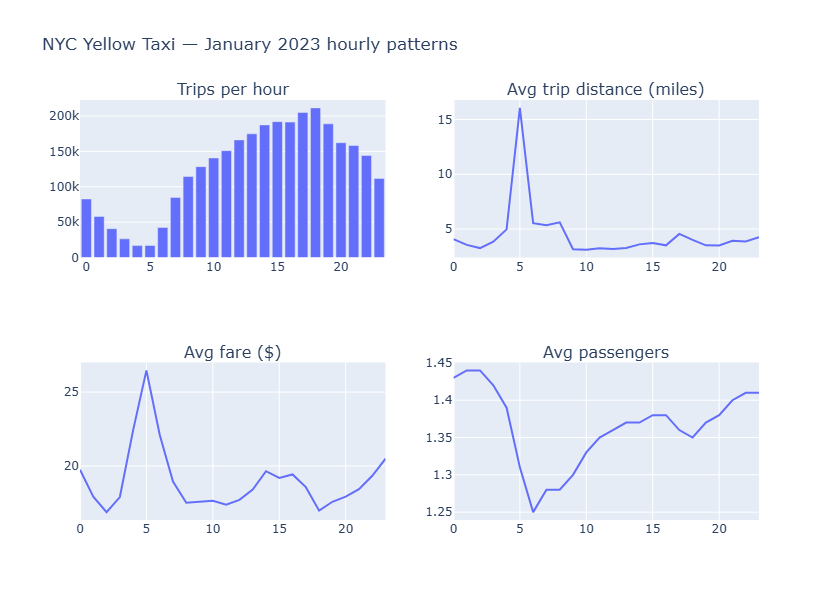

In [2]:
## NYC Yellow Taxi Hourly Analysis - January 2023

import os
import sys

# ================================================
# Environment Configuration
# ================================================

os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"

# ================================================
# Imports
# ================================================

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, hour, avg, count
from pyspark.sql.functions import round as spark_round

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ================================================
# Initialize Spark Session
# ================================================

spark = (
    SparkSession.builder
    .appName("Taxi Plotting")
    .config("spark.driver.host", "localhost")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

# ================================================
# Read and Process Data
# ================================================

df = spark.read.parquet("../data/taxi/yellow_tripdata_2023-01.parquet")

hourly_sdf = (
    df.withColumn("pickup_hour", hour("tpep_pickup_datetime"))
      .filter(
          (col("trip_distance") > 0) &
          (col("fare_amount")   > 0) &
          (col("fare_amount")   < 200)
      )
      .groupBy("pickup_hour")
      .agg(
          count("*").alias("n_trips"),
          spark_round(avg("trip_distance"),   2).alias("avg_distance"),
          spark_round(avg("fare_amount"),     2).alias("avg_fare"),
          spark_round(avg("passenger_count"), 2).alias("avg_passengers"),
      )
      .orderBy("pickup_hour")
)

# ================================================
# Create the Plot
# ================================================

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        "Trips per hour",
        "Avg trip distance (miles)",
        "Avg fare ($)",
        "Avg passengers",
    ]
)

plots = [
    ("n_trips",        "bar",  1, 1),
    ("avg_distance",   "line", 1, 2),
    ("avg_fare",       "line", 2, 1),
    ("avg_passengers", "line", 2, 2),
]

for metric, kind, row, col_ in plots:
    sub_fig = hourly_sdf.plot(kind=kind, x="pickup_hour", y=metric)
    for trace in sub_fig.data:
        fig.add_trace(trace, row=row, col=col_)

fig.update_layout(
    title_text="NYC Yellow Taxi — January 2023 hourly patterns",
    height=600,
    showlegend=False,
)

# ================================================
# Save the Plot
# ================================================
# Create the directory (and any missing parent directories) if it doesn't exist yet
os.makedirs("../outputs", exist_ok=True)

# 1. Save as interactive HTML file (recommended)
fig.write_html("../outputs/spark_nyc_taxi_hourly_patterns.html")

# 2. Save as static PNG image
# Note: This requires kaleido (install with: pip install -U kaleido)
fig.write_image("../outputs/spark_nyc_taxi_hourly_patterns.png", 
                width=1200, 
                height=600, 
                scale=2)   # scale=2 makes it higher resolution

print("✅ Plot saved to '../outputs/' successfully!")
print("   • nyc_taxi_hourly_patterns.html  (interactive version)")
print("   • nyc_taxi_hourly_patterns.png    (static image)")

# Display the plot in the notebook
fig.show()